In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics
import seaborn as sns

vs = pd.read_csv("variablestar_subset.csv")
diasource = pd.read_csv("diasource.csv")
diaobject = pd.read_csv("diaobject.csv")

In [199]:
vs.columns

Index(['diaObjectId', 'ra', 'dec', 'g_psfFluxMean', 'r_psfFluxMean',
       'i_psfFluxMean', 'g_psfFluxSigma', 'r_psfFluxSigma', 'i_psfFluxSigma',
       'g_psfFluxChi2', 'r_psfFluxChi2', 'i_psfFluxChi2', 'g_psfFluxStetsonJ',
       'r_psfFluxStetsonJ', 'i_psfFluxStetsonJ', 'g_psfFluxMAD',
       'r_psfFluxMAD', 'i_psfFluxMAD', 'g_psfFluxNdata', 'r_psfFluxNdata',
       'i_psfFluxNdata', 'nDiaSources', 'Region', 'Class', 'otype',
       'otype_flag', 'g_psfFluxPercentile95', 'r_psfFluxPercentile95',
       'i_psfFluxPercentile95', 'g_psfFluxPercentile50',
       'r_psfFluxPercentile50', 'i_psfFluxPercentile50',
       'g_psfFluxPercentile05', 'r_psfFluxPercentile05',
       'i_psfFluxPercentile05', 'g_psfFluxLinearSlope', 'r_psfFluxLinearSlope',
       'i_psfFluxLinearSlope', 'g_psfFluxMaxSlope', 'r_psfFluxMaxSlope',
       'i_psfFluxMaxSlope', 'g_psfFluxSkew', 'r_psfFluxSkew', 'i_psfFluxSkew',
       'g_scienceFluxMean', 'r_scienceFluxMean', 'i_scienceFluxMean', 'gmag',
       'rmag',

In [200]:
vs["rmag_std_dev"] = vs["r_psfFluxSigma"] / vs["r_psfFluxMean"]
# don't have to calculate chi2, stetsonJ, or magnitude since we have all of that alr.

In [201]:
vs = vs.rename(columns={
    'r_psfFluxChi2': 'r_chi2',
    'rmag_std_dev': 'r_mag_std',
    'r_psfFluxStetsonJ' : 'r_stetsonJ'
})
vs.to_csv("vs_but_dia.csv", index=False)
vs2 = pd.read_csv("vs_but_dia.csv")

In [208]:
def scatter_variability_metrics(bottom, top, x, y, hue=None, title = None, log_x = True, log_y = True, zorder = 1):
    plt.figure(figsize=(6, 5))
    
    sns.scatterplot(data=bottom, x=x, y=y, color = "red",
                    alpha=0.4, s=10, zorder=1, label = "Unlabeled", legend=False)

    sns.scatterplot(data=top, x=x, y=y, color = "green",
                    alpha=0.7, s=12, zorder=2, label = "Labeled")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title or f"{x} vs {y}")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.legend()
    plt.show()

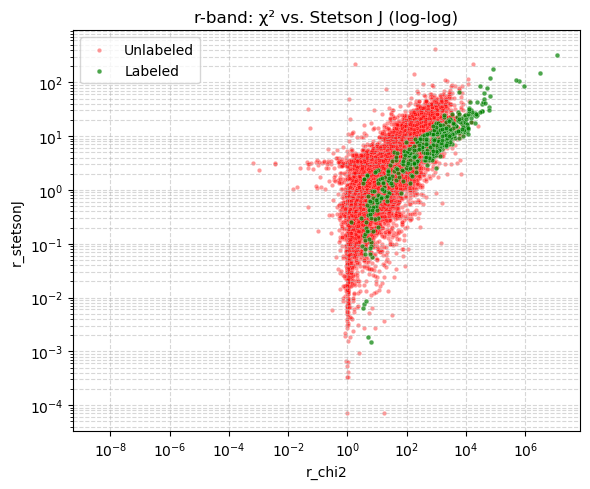

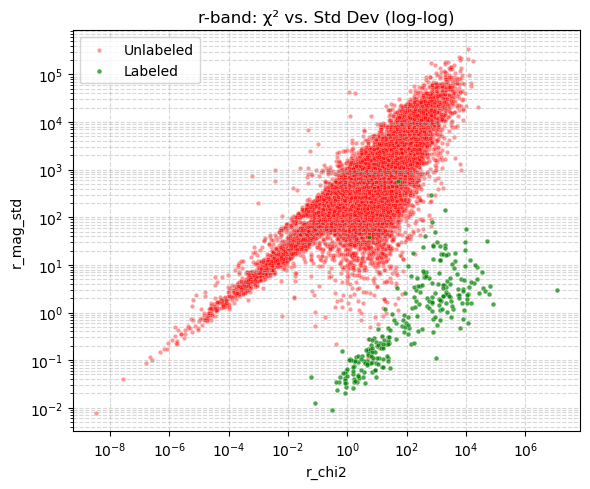

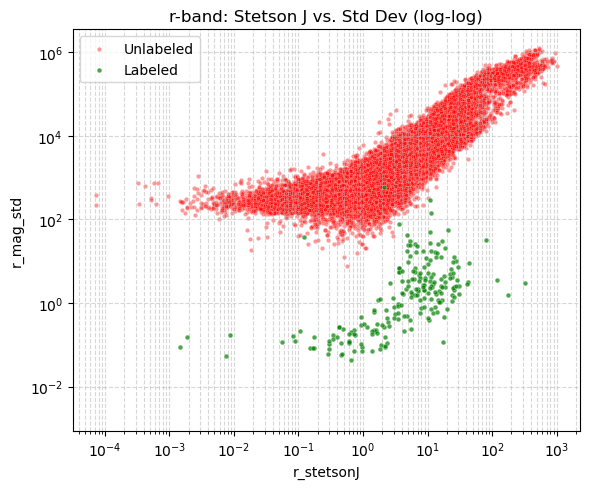

In [209]:
scatter_variability_metrics(diaobject, vs2, x="r_chi2", y="r_stetsonJ", title = "r-band: χ² vs. Stetson J (log-log)", zorder = 2)
scatter_variability_metrics(diaobject, vs2, x="r_chi2", y="r_mag_std", title="r-band: χ² vs. Std Dev (log-log)", zorder = 2)
scatter_variability_metrics(diaobject, vs2, x="r_stetsonJ", y="r_mag_std", title="r-band: Stetson J vs. Std Dev (log-log)", zorder = 2)

In [205]:
common_ids = set(vs2["diaObjectId"]) & set(diaobject["diaObjectId"])
print("Matching diaObjectIds:", len(common_ids))

Matching diaObjectIds: 550


# Information

Labeled stars behave significantly different opposed to the DP1 population. They
1) have high chi squares, meaning they are statistically significant
2) have low magnitude standard deviation, meaning that they are clean